# 환경 설정

In [ ]:
#폰트 설치
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

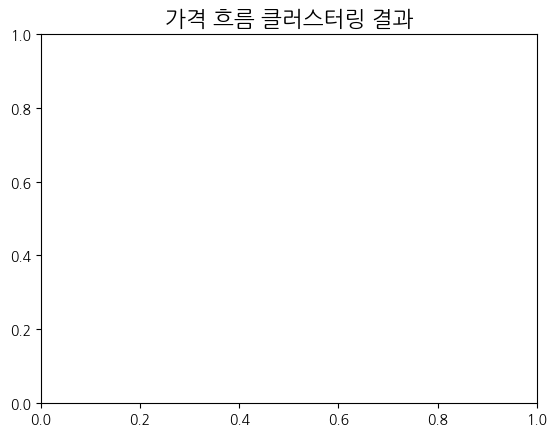

In [24]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# 나눔고딕 설정
mpl.rc('font', family='NanumGothic')  # 한글 폰트 설정
mpl.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

# 나눔 고딕 폰트로 텍스트 출력 확인
plt.title("가격 흐름 클러스터링 결과", fontsize=16)
plt.show()

In [ ]:
!pip install pykrx
!pip install pykrx yfinance

# 크롤링

In [ ]:
from pykrx import stock
from datetime import datetime, timedelta
import yfinance as yf
import sqlite3
import time

# 최근 영업일 찾기
def get_latest_trading_day():
    today = datetime.today()
    for i in range(10):
        check_day = (today - timedelta(days=i)).strftime('%Y-%m-%d')
        try:
            df = stock.get_market_cap_by_ticker(check_day, market="KOSPI")
            if not df.empty:
                return check_day
        except:
            continue
    raise Exception("최근 10일 안에 영업일 없음!")

# 시가총액 상위 200종목 가져오기
def get_top_200_tickers():
    latest_day = get_latest_trading_day()
    df = stock.get_market_cap_by_ticker(latest_day, market="KOSPI")
    top200 = df.sort_values(by="시가총액", ascending=False).head(200)
    return top200.index.tolist(), latest_day

# KRX 코드 → Yahoo Finance 형식으로 변환
def convert_to_yahoo(ticker):
    return ticker + ".KS"

def get_combined_fundamentals(krx_ticker, yahoo_ticker, date):
    # yfinance 데이터 우선
    stock_obj = yf.Ticker(yahoo_ticker)
    info = stock_obj.info

    try:
        recent_quarter = stock_obj.quarterly_financials.columns[0]
        revenue = stock_obj.quarterly_financials.loc["Total Revenue", recent_quarter]
        revenue = int(revenue) if isinstance(revenue, (float, int)) else None
    except:
        revenue = None

    # 우선 yfinance 데이터
    data = {
        "ticker": krx_ticker,
        "name": info.get("shortName"),
        "sector": info.get("sector"),
        "marketCap": info.get("marketCap"),
        "trailingPE": info.get("trailingPE"),
        "forwardPE": info.get("forwardPE"),
        "returnOnEquity": info.get("returnOnEquity"),
        "priceToBook": info.get("priceToBook"),
        "dividendYield": info.get("dividendYield"),
        "eps": info.get("epsTrailingTwelveMonths"),
        "recentRevenue": revenue,
        "beta": info.get("beta"),
        "fiftyTwoWeekHigh": info.get("fiftyTwoWeekHigh"),
        "fiftyTwoWeekLow": info.get("fiftyTwoWeekLow"),
        "averageVolume": info.get("averageVolume"),
        "profitMargins": info.get("profitMargins"),
        "debtToEquity": info.get("debtToEquity"),
        "currentRatio": info.get("currentRatio"),
        "operatingMargins": info.get("operatingMargins")
    }

    # 보완: yfinance 값이 None이면 pykrx로 대체
    try:
        df = stock.get_market_fundamental_by_ticker(date, market="KOSPI")
        if krx_ticker in df.index:
            row = df.loc[krx_ticker]
            if data["trailingPE"] is None:
                data["trailingPE"] = row["PER"]
            if data["priceToBook"] is None:
                data["priceToBook"] = row["PBR"]
            if data["eps"] is None:
                data["eps"] = row["EPS"]
    except:
        pass

    return data


# DB 초기화
def init_db():
    conn = sqlite3.connect("kospi_financials.db")
    cursor = conn.cursor()
    cursor.execute("""
    CREATE TABLE IF NOT EXISTS financials (
        ticker TEXT PRIMARY KEY,
        name TEXT,
        sector TEXT,
        marketCap INTEGER,
        trailingPE REAL,
        forwardPE REAL,
        returnOnEquity REAL,
        priceToBook REAL,
        dividendYield REAL,
        eps REAL,
        recentRevenue INTEGER,
        beta REAL,
        fiftyTwoWeekHigh REAL,
        fiftyTwoWeekLow REAL,
        averageVolume INTEGER,
        profitMargins REAL,
        debtToEquity REAL,
        currentRatio REAL,
        operatingMargins REAL
    )
    """)
    conn.commit()
    return conn, cursor

# DB 저장
def save_to_db(cursor, conn, data):
    cursor.execute("""
        INSERT OR REPLACE INTO financials
        VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, tuple(data.values()))
    conn.commit()

# 전체 실행
def main():
    print("📦 SQLite DB 초기화")
    conn, cursor = init_db()

    print("📈 시가총액 상위 200개 종목 가져오는 중...")
    tickers_krx, latest_day = get_top_200_tickers()
    yahoo_tickers = [convert_to_yahoo(t) for t in tickers_krx]

    for krx_ticker, yahoo_ticker in zip(tickers_krx, yahoo_tickers):
        try:
            data = get_combined_fundamentals(krx_ticker, yahoo_ticker, latest_day)
            save_to_db(cursor, conn, data)
            print(f"✅ 저장 완료: {data['name']} ({krx_ticker})")
            time.sleep(1)  # API 호출 간 딜레이
        except Exception as e:
            print(f"❌ 에러 - {krx_ticker}: {e}")

    conn.close()
    print("🎉 완료! 데이터가 'kospi_financials.db'에 저장되었습니다.")

# 실행
if __name__ == "__main__":
    main()


# 주별 주가 흐름 기반 상관계수 행렬 만들기

In [4]:
from pykrx import stock
from datetime import datetime, timedelta
import yfinance as yf
import pandas as pd

# 최근 영업일 찾기
def get_latest_trading_day():
    today = datetime.today()
    for i in range(10):
        check_day = (today - timedelta(days=i)).strftime('%Y-%m-%d')
        try:
            df = stock.get_market_cap_by_ticker(check_day, market="KOSPI")
            if not df.empty:
                return check_day
        except:
            continue
    raise Exception("최근 10일 안에 영업일 없음!")

# 유효한 상위 종목 찾기
def get_valid_top_tickers(top_n=200):
    latest_day = get_latest_trading_day()
    df = stock.get_market_cap_by_ticker(latest_day, market="KOSPI")
    top_df = df.sort_values(by="시가총액", ascending=False).head(top_n)

    tickers_krx = top_df.index.tolist()
    tickers_yahoo = [ticker + ".KS" for ticker in tickers_krx]

    print("📥 유효한 종목 필터링 중...")
    valid_tickers = []
    for krx_ticker, y_ticker in zip(tickers_krx, tickers_yahoo):
        try:
            df = yf.download(y_ticker, period="1y", interval="1wk")["Close"]
            if df.dropna().shape[0] > 30:
                valid_tickers.append(krx_ticker)
        except:
            continue

    print(f"✅ 유효한 종목 수: {len(valid_tickers)}개")
    return valid_tickers, latest_day

# 주간 종가 및 수익률 분석 → 저장
def analyze_price_correlation(tickers):
    yahoo_tickers = [ticker + ".KS" for ticker in tickers]
    print("📥 주간 종가 수집 중...")
    data = yf.download(yahoo_tickers, period="1y", interval="1wk")["Close"]

    data.to_csv("weekly_close_prices.csv")
    print("💾 'weekly_close_prices.csv' 저장 완료!")

    weekly_returns = data.pct_change().dropna()
    weekly_returns.to_csv("weekly_returns.csv")
    print("💾 'weekly_returns.csv' 저장 완료!")

    corr_matrix = weekly_returns.corr()
    corr_matrix.to_csv("weekly_price_correlation.csv")
    print("💾 'weekly_price_correlation.csv' 저장 완료!")

    return corr_matrix, weekly_returns

# 전체 실행
def main():
    print("📊 상위 시가총액 종목 불러오는 중...")
    tickers_krx, _ = get_valid_top_tickers(top_n=200)

    print("🧠 데이터 수집 및 저장 중...")
    analyze_price_correlation(tickers_krx)

    print("🎉 완료! 클러스터링에 필요한 CSV 파일들이 저장되었습니다.")

if __name__ == "__main__":
    main()


📊 상위 시가총액 종목 불러오는 중...
📥 유효한 종목 필터링 중...


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

✅ 유효한 종목 수: 196개
🧠 데이터 수집 및 저장 중...
📥 주간 종가 수집 중...


[*********************100%***********************]  196 of 196 completed


💾 'weekly_close_prices.csv' 저장 완료!
💾 'weekly_returns.csv' 저장 완료!
💾 'weekly_price_correlation.csv' 저장 완료!
🎉 완료! 클러스터링에 필요한 CSV 파일들이 저장되었습니다.


📂 'weekly_returns.csv' 불러오는 중...
🔍 정규화 중...
📉 PCA 차원 축소 중...
📊 최적 클러스터 수 탐색 중 (실루엣 점수 기반)...
✅ 최적 클러스터 수: 2 (실루엣 점수: 0.4954)


/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The defa

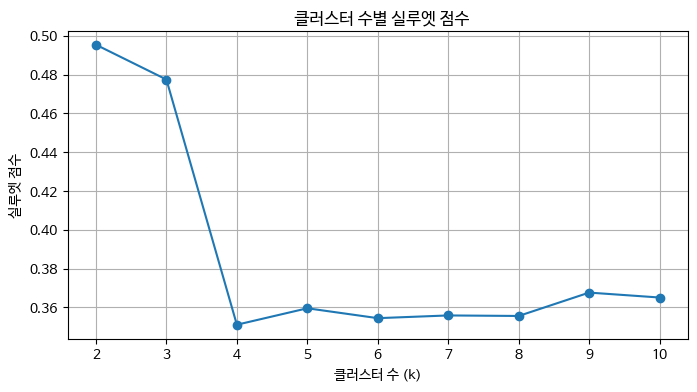

🤖 최종 클러스터링 수행 중...
🧭 2D 시각화 중...


/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


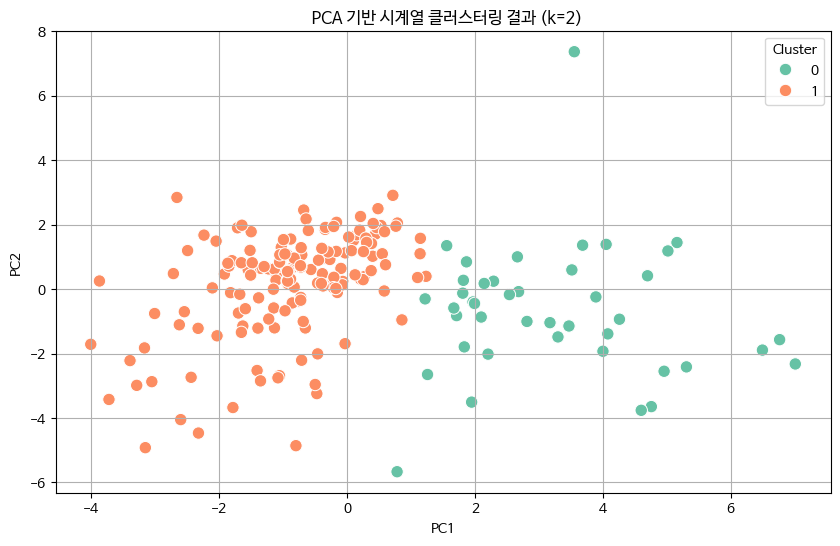

✅ 클러스터링 결과 'clustered_tickers.csv' 저장 완료!


In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

def cluster_weekly_returns(csv_path="weekly_returns.csv", max_clusters=10):
    print(f"📂 '{csv_path}' 불러오는 중...")
    weekly_returns = pd.read_csv(csv_path, index_col=0)

    print("🔍 정규화 중...")
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(weekly_returns.T)

    print("📉 PCA 차원 축소 중...")
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(scaled_data)

    print("📊 최적 클러스터 수 탐색 중 (실루엣 점수 기반)...")
    best_score = -1
    best_k = 2
    scores = []

    for k in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(pca_data)
        score = silhouette_score(pca_data, labels)
        scores.append((k, score))
        if score > best_score:
            best_score = score
            best_k = k

    print(f"✅ 최적 클러스터 수: {best_k} (실루엣 점수: {best_score:.4f})")

    # 실루엣 점수 시각화
    ks, sil_scores = zip(*scores)
    plt.figure(figsize=(8, 4))
    plt.plot(ks, sil_scores, marker='o')
    plt.title("📈 클러스터 수별 실루엣 점수")
    plt.xlabel("클러스터 수 (k)")
    plt.ylabel("실루엣 점수")
    plt.grid(True)
    plt.show()

    print("🤖 최종 클러스터링 수행 중...")
    kmeans = KMeans(n_clusters=best_k, random_state=42)
    labels = kmeans.fit_predict(pca_data)

    print("🧭 2D 시각화 중...")
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=labels, palette='Set2', s=80)
    plt.title(f"📌 PCA 기반 시계열 클러스터링 결과 (k={best_k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.legend(title="Cluster")
    plt.show()

    clustered_df = pd.DataFrame({
        "Ticker": weekly_returns.columns,
        "Cluster": labels
    })
    clustered_df.to_csv("clustered_tickers.csv", index=False)
    print("✅ 클러스터링 결과 'clustered_tickers.csv' 저장 완료!")

    return clustered_df, best_k, best_score

clustered_df, best_k, best_score = cluster_weekly_returns(max_clusters=10)


#####tiker = 주식 티커 번호
#####name = 주식회사 이름
#####sector = 주식 해당 섹터
#####marketCap = 시가총액
#####trailingPE = 과거 실적 기준 주가수익비율 (현재주가 / 지난 12개월 순이익(EPS)
#####forwardPE = 향후 12개월 예상 실적 기준 주가 수익 비율 (현재 주가 / 예상 EPS)
#####dividendYield = 배당수익률 (주가 대비 배당금 비율)

#####eps = 주당수익 (기업이 벌어들인 이익 / 주식 수)

#####recentRevenue = 최근 매출 (분기)

#####averageVolume = 평균 거래량

#####profitMargins = 순이익률

#####currentRatio = 유동비율

##### operatingMargins = 영업이익률

# 주가흐름 클러스터링 (AgglomerativeClustering)

In [ ]:
!pip install tslearn
!pip install python-louvain
!pip install seaborn

📂 'weekly_returns.csv' 불러오는 중...
🔍 정규화 중...
📉 PCA 차원 축소 중...
📊 최적 클러스터 수 탐색 중 (실루엣 점수 기반 및 추가 지표 계산)...
✅ 최적 클러스터 수: 3 (실루엣 점수: 0.4827)


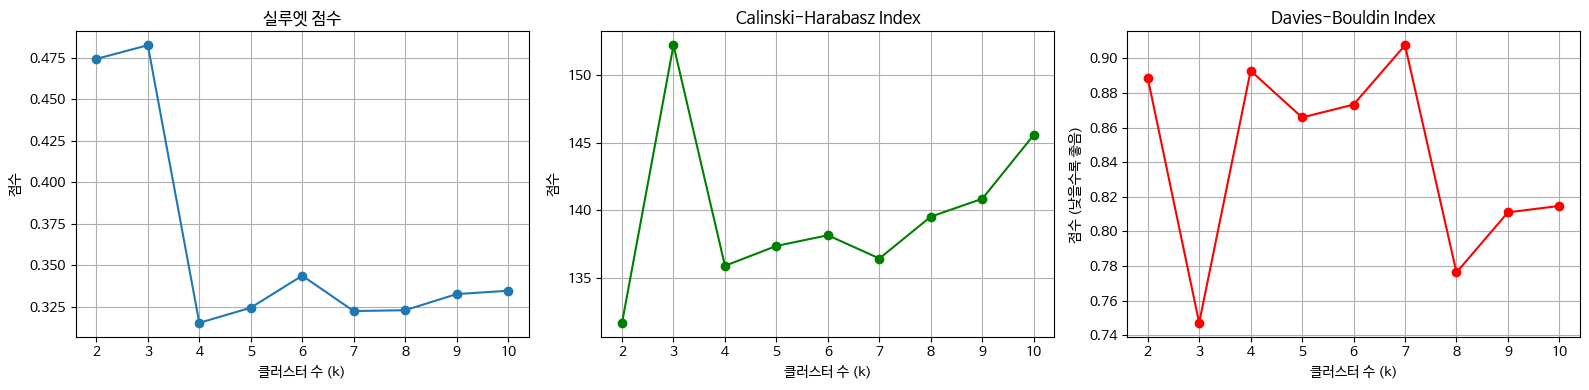

🤖 최종 클러스터링 수행 중...
최종 클러스터링 지표 (k=3):
 - Silhouette Score: 0.4827
 - Calinski-Harabasz Index: 152.2336
 - Davies-Bouldin Index: 0.7472
🧭 2D 시각화 중...


/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


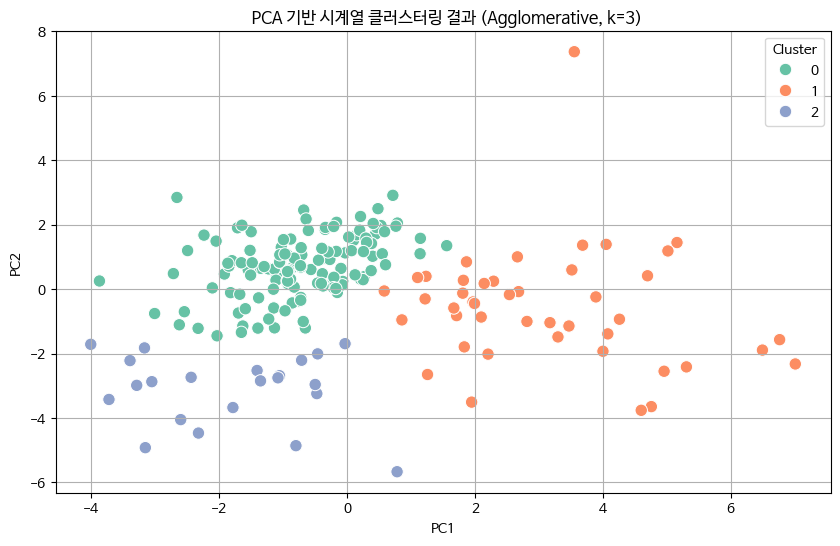

✅ 클러스터링 결과 'clustered_tickers_agglomerative.csv' 저장 완료!


In [38]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

def cluster_weekly_returns_agglomerative(csv_path="weekly_returns.csv", max_clusters=10):
    print(f"📂 '{csv_path}' 불러오는 중...")
    weekly_returns = pd.read_csv(csv_path, index_col=0)

    print("🔍 정규화 중...")
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(weekly_returns.T)

    print("📉 PCA 차원 축소 중...")
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(scaled_data)

    print("📊 최적 클러스터 수 탐색 중 (실루엣 점수 기반 및 추가 지표 계산)...")
    best_score = -1
    best_k = 2
    scores = []  # (k, silhouette, calinski_harabasz, davies_bouldin)

    for k in range(2, max_clusters + 1):
        model = AgglomerativeClustering(n_clusters=k)
        labels = model.fit_predict(pca_data)

        sil_score = silhouette_score(pca_data, labels)
        ch_score = calinski_harabasz_score(pca_data, labels)
        db_score = davies_bouldin_score(pca_data, labels)

        scores.append((k, sil_score, ch_score, db_score))

        if sil_score > best_score:
            best_score = sil_score
            best_k = k

    print(f"✅ 최적 클러스터 수: {best_k} (실루엣 점수: {best_score:.4f})")

    # 각 지표별 시각화
    ks, sil_scores, ch_scores, db_scores = zip(*scores)

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 3, 1)
    plt.plot(ks, sil_scores, marker='o')
    plt.title("실루엣 점수")
    plt.xlabel("클러스터 수 (k)")
    plt.ylabel("점수")
    plt.grid(True)

    plt.subplot(1, 3, 2)
    plt.plot(ks, ch_scores, marker='o', color='green')
    plt.title("Calinski-Harabasz Index")
    plt.xlabel("클러스터 수 (k)")
    plt.ylabel("점수")
    plt.grid(True)

    plt.subplot(1, 3, 3)
    plt.plot(ks, db_scores, marker='o', color='red')
    plt.title("Davies-Bouldin Index")
    plt.xlabel("클러스터 수 (k)")
    plt.ylabel("점수 (낮을수록 좋음)")
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("🤖 최종 클러스터링 수행 중...")
    final_model = AgglomerativeClustering(n_clusters=best_k)
    final_labels = final_model.fit_predict(pca_data)

    # 최적 k에서의 모든 지표 출력
    final_sil = silhouette_score(pca_data, final_labels)
    final_ch = calinski_harabasz_score(pca_data, final_labels)
    final_db = davies_bouldin_score(pca_data, final_labels)

    print(f"최종 클러스터링 지표 (k={best_k}):")
    print(f" - Silhouette Score: {final_sil:.4f}")
    print(f" - Calinski-Harabasz Index: {final_ch:.4f}")
    print(f" - Davies-Bouldin Index: {final_db:.4f}")

    print("🧭 2D 시각화 중...")
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=pca_data[:, 0], y=pca_data[:, 1], hue=final_labels, palette='Set2', s=80)
    plt.title(f"📌 PCA 기반 시계열 클러스터링 결과 (Agglomerative, k={best_k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.legend(title="Cluster")
    plt.show()

    clustered_df = pd.DataFrame({
        "Ticker": weekly_returns.columns,
        "Cluster": final_labels
    })
    clustered_df.to_csv("clustered_tickers_agglomerative.csv", index=False)
    print("✅ 클러스터링 결과 'clustered_tickers_agglomerative.csv' 저장 완료!")

    return clustered_df, best_k, best_score

if __name__ == "__main__":
    cluster_weekly_returns_agglomerative(max_clusters=10)


# 주가흐름 클러스터링 (LSTM Autoencoder+ Kmeans)

In [19]:
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 479.6/479.6 MB 19.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 19.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 13.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 13.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 9.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 12.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 16.7 MB/s eta 0:00:00a 0:00:01
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.13.2
    Uninstalling typing_extensions-4.13.2:
      Successfully uninstalled typing_extensions-4.13.2
  Attempting uninstall: protobuf
   

In [25]:
!pip install hdbscan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 16.6 MB/s eta 0:00:00a 0:00:01


🤖 LSTM Autoencoder 학습 시작...
Epoch 1/100
11/11 [==============================] - 1s 37ms/step - loss: 0.9781 - val_loss: 1.3108
Epoch 2/100
11/11 [==============================] - 0s 19ms/step - loss: 0.9613 - val_loss: 1.3004
Epoch 3/100
11/11 [==============================] - 0s 18ms/step - loss: 0.9506 - val_loss: 1.2928
Epoch 4/100
11/11 [==============================] - 0s 18ms/step - loss: 0.9403 - val_loss: 1.2875
Epoch 5/100
11/11 [==============================] - 0s 19ms/step - loss: 0.9371 - val_loss: 1.2841
Epoch 6/100
11/11 [==============================] - 0s 19ms/step - loss: 0.9369 - val_loss: 1.2872
Epoch 7/100
11/11 [==============================] - 0s 17ms/step - loss: 0.9388 - val_loss: 1.2836
Epoch 8/100
11/11 [==============================] - 0s 19ms/step - loss: 0.9362 - val_loss: 1.2808
Epoch 9/100
11/11 [==============================] - 0s 19ms/step - loss: 0.9343 - val_loss: 1.2790
Epoch 10/100
11/11 [==============================] - 0s 18ms/step - los

/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The defa

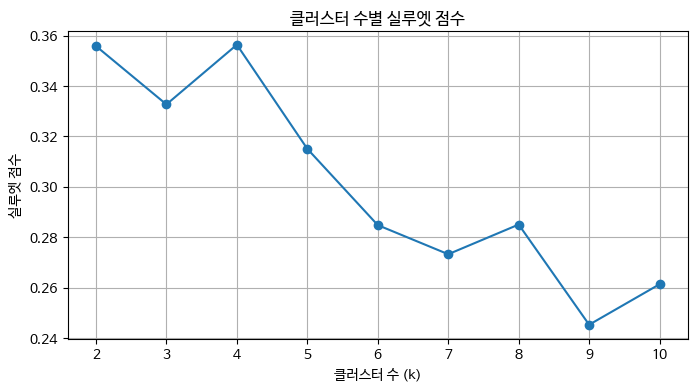

최적 클러스터 수: 4 (실루엣 점수: 0.3563)
🤖 최적 클러스터 수로 KMeans 클러스터링 중...
✅ 클러스터링 완료! 실루엣 점수: 0.3563


/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


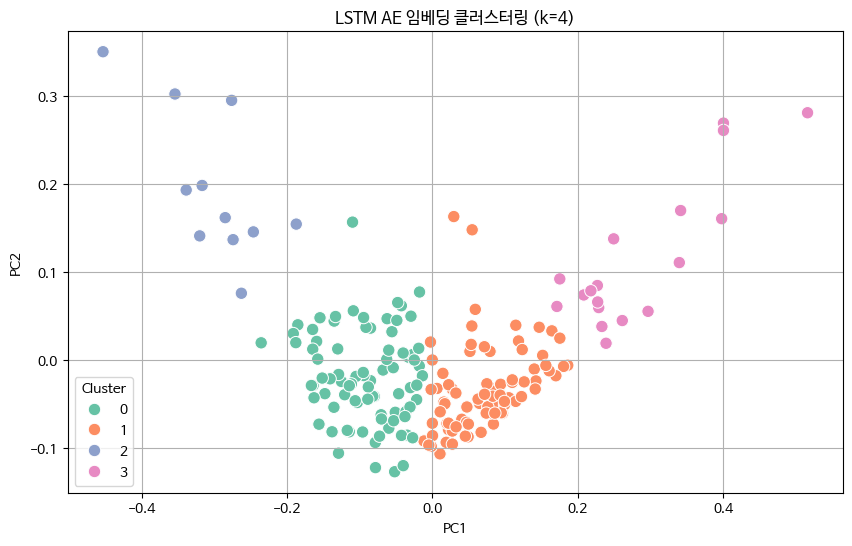

✅ 'clustered_tickers_lstm_ae.csv' 저장 완료!


In [36]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# build_lstm_autoencoder 함수는 반드시 구현되어 있어야 합니다.
# 예시로 간단한 LSTM Autoencoder 정의 (TensorFlow / Keras 필요)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, RepeatVector

def build_lstm_autoencoder(timesteps, latent_dim=16):
    inputs = Input(shape=(timesteps,1))
    encoded = LSTM(latent_dim, activation='relu')(inputs)
    decoded = RepeatVector(timesteps)(encoded)
    decoded = LSTM(1, activation='linear', return_sequences=True)(decoded)
    autoencoder = Model(inputs, decoded)
    encoder = Model(inputs, encoded)
    autoencoder.compile(optimizer='adam', loss='mse')
    return autoencoder, encoder

def find_best_k_from_embeddings(embeddings, max_clusters=10):
    best_score = -1
    best_k = 2
    scores = []

    for k in range(2, max_clusters + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(embeddings)
        score = silhouette_score(embeddings, labels)
        scores.append((k, score))
        if score > best_score:
            best_score = score
            best_k = k

    ks, sil_scores = zip(*scores)
    plt.figure(figsize=(8, 4))
    plt.plot(ks, sil_scores, marker='o')
    plt.title("클러스터 수별 실루엣 점수")
    plt.xlabel("클러스터 수 (k)")
    plt.ylabel("실루엣 점수")
    plt.grid(True)
    plt.show()

    print(f"최적 클러스터 수: {best_k} (실루엣 점수: {best_score:.4f})")
    return best_k

def cluster_with_lstm_ae_auto_k(data_scaled, tickers, max_clusters=10, epochs=100, batch_size=16):
    data_reshaped = data_scaled[..., np.newaxis]
    timesteps = data_reshaped.shape[1]
    autoencoder, encoder = build_lstm_autoencoder(timesteps)

    print("🤖 LSTM Autoencoder 학습 시작...")
    autoencoder.fit(data_reshaped, data_reshaped,
                    epochs=epochs,
                    batch_size=batch_size,
                    validation_split=0.1,
                    verbose=1)

    print("📉 임베딩 추출 중...")
    embeddings = encoder.predict(data_reshaped)

    best_k = find_best_k_from_embeddings(embeddings, max_clusters=max_clusters)

    print("🤖 최적 클러스터 수로 KMeans 클러스터링 중...")
    kmeans = KMeans(n_clusters=best_k, random_state=42)
    labels = kmeans.fit_predict(embeddings)
    sil_score = silhouette_score(embeddings, labels)
    print(f"✅ 클러스터링 완료! 실루엣 점수: {sil_score:.4f}")

    pca = PCA(n_components=2)
    pca_embeds = pca.fit_transform(embeddings)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=pca_embeds[:, 0], y=pca_embeds[:, 1], hue=labels, palette='Set2', s=80)
    plt.title(f"LSTM AE 임베딩 클러스터링 (k={best_k})")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.grid(True)
    plt.legend(title="Cluster")
    plt.show()

    clustered_df = pd.DataFrame({"Ticker": tickers, "Cluster": labels})
    clustered_df.to_csv("clustered_tickers_lstm_ae.csv", index=False)
    print("✅ 'clustered_tickers_lstm_ae.csv' 저장 완료!")

    return clustered_df, best_k, sil_score

# ===== 실행 예시 =====

if __name__ == "__main__":
    # 예시: weekly_returns.csv 파일에서 데이터 불러와서 정규화
    weekly_returns = pd.read_csv("weekly_returns.csv", index_col=0)
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(weekly_returns.T)  # transpose: 종목별 시계열

    tickers = weekly_returns.columns.tolist()

    clustered_df, best_k, sil_score = cluster_with_lstm_ae_auto_k(
        data_scaled,
        tickers,
        max_clusters=10,
        epochs=100,         # 학습 속도 및 자원 고려해 줄임
        batch_size=16
    )


In [52]:
!pip install pykrx

### GCN 기반 기업들 유사한 재무적 특성을 기준으로 군집화

### 서로 재무지표 유사도가 0.85보다 크면 엣지로 연결

### 연결 구조와 재무지표를 함께 고려한 표현

### GCN 임베딩이 9차원이므로 UMAP으로 2D 시각화

In [ ]:
!pip install torch
!pip install numpy


In [ ]:
!pip install torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric -f https://data.pyg.org/whl/torch-2.0.0+cu118.html

In [25]:
!pip install umap-learn

In [ ]:
# ✅ 기존 설치 제거
!pip uninstall -y torch torchvision torchaudio torch-scatter torch-sparse torch-cluster torch-spline-conv torch-geometric

# ✅ 권장 버전 설치 (PyTorch 2.0.1 기준 안정 조합)
!pip install torch==2.0.1 torchvision==0.15.2 torchaudio==2.0.2
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.0.1+cu118.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.0.1+cu118.html
!pip install torch-cluster -f https://data.pyg.org/whl/torch-2.0.1+cu118.html
!pip install torch-spline-conv -f https://data.pyg.org/whl/torch-2.0.1+cu118.html
!pip install torch-geometric


# GCN+UMAP+kmeans 재무지표 클러스터링

In [ ]:
# 📦 라이브러리 불러오기
import sqlite3
import random

import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from umap import UMAP

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(40)
# 1️⃣ DB에서 재무지표 불러오기
conn = sqlite3.connect('/home/KHLee/hojin/kospi_financials200.db')

selected_columns = [
    'marketCap', 'trailingPE', 'forwardPE', 'returnOnEquity',
    'priceToBook', 'eps', 'recentRevenue', 'profitMargins', 'debtToEquity'
]

query = f"""
SELECT ticker, name, sector, {', '.join(selected_columns)}
FROM financials
"""
df = pd.read_sql(query, conn).dropna()

tickers = df['ticker'].values
names = df['name'].values
sectors = df['sector'].values

features = df[selected_columns].astype(float)
scaled = StandardScaler().fit_transform(features)

# 2️⃣ 재무지표 기반 유사도 계산
S_fund = pd.DataFrame(np.corrcoef(scaled), index=tickers, columns=tickers)

# 3️⃣ 그래프 생성 (유사도 기반 엣지 연결)
G = nx.Graph()
for i in tickers:
    G.add_node(i)
    for j in tickers:
        if i != j and S_fund.loc[i, j] > 0.85:
            G.add_edge(i, j, weight=S_fund.loc[i, j])

# ✅ 인덱스 매핑 및 edge_index 생성
ticker_to_idx = {ticker: i for i, ticker in enumerate(tickers)}
edge_list = [(ticker_to_idx[i], ticker_to_idx[j]) for i, j in G.edges if i in ticker_to_idx and j in ticker_to_idx]
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()


# 4️⃣ 노드 특징 행렬 (재무지표)
x = torch.tensor(scaled, dtype=torch.float)

# 5️⃣ GCN 정의
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# 6️⃣ 학습 준비
data = Data(x=x, edge_index=edge_index)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 🔥 출력 차원을 9로 맞춤!
model = GCN(in_channels=x.size(1), hidden_channels=8, out_channels=x.size(1)).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.mse_loss(out, data.x)  # autoencoder 방식
    loss.backward()
    optimizer.step()

# 7️⃣ 임베딩 추출 & UMAP 차원 축소
model.eval()
with torch.no_grad():
    z = model(data.x, data.edge_index).cpu().numpy()

z_umap = UMAP(n_neighbors=5, min_dist=0.6, random_state=42).fit_transform(z)

# 8️⃣ 클러스터링
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(z_umap)

# 9️⃣ 시각화
df_plot = pd.DataFrame(z_umap, columns=['x', 'y'])
df_plot['ticker'] = tickers
df_plot['name'] = names
df_plot['sector'] = sectors
df_plot['cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='x', y='y', hue='cluster', palette='Set2', s=100)
for i in range(len(tickers)):
    plt.text(df_plot['x'][i]+0.03, df_plot['y'][i], df_plot['ticker'][i], fontsize=8)
plt.title(" KOSPI 200 GCN Embedding + UMAP + Clustering")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 🔟 클러스터별 기업 목록
df_summary = df_plot[['ticker', 'name', 'sector', 'cluster']].sort_values('cluster')

# 📋 각 클러스터에 속한 기업 목록 CSV로 저장
# df_summary.to_csv("/content/clustered_companies_kospi_200.csv", index=False)

print("\n📋 각 클러스터에 속한 기업을 'clustered_companies_kospi_200.csv'로 저장했습니다.")
print(df_summary.to_string(index=False))

# ✅ 클러스터별 기업 수 출력
cluster_counts = df_plot["cluster"].value_counts().sort_index()
print("\n📊 클러스터별 기업 수:")
print(cluster_counts)

# 📊 클러스터별 기업 수 CSV로 저장
# Series를 DataFrame으로 변환 후 저장
cluster_counts_df = cluster_counts.reset_index()
cluster_counts_df.columns = ["Cluster", "Count"]
# cluster_counts_df.to_csv("/content/cluster_counts_kospi_200.csv", index=False)


/home/KHLee/miniconda3/envs/hojin/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OperationalError: unable to open database file

#  GCN + UMAP + SPECTRAL CLUSTERING 재무지표

클러스터 수: 2, 실루엣 점수: 0.4558
클러스터 수: 3, 실루엣 점수: 0.4696
클러스터 수: 4, 실루엣 점수: 0.4576
클러스터 수: 5, 실루엣 점수: 0.4901
클러스터 수: 6, 실루엣 점수: 0.5200
클러스터 수: 7, 실루엣 점수: 0.5488
클러스터 수: 8, 실루엣 점수: 0.5122
클러스터 수: 9, 실루엣 점수: 0.5583

✨ 최적 클러스터 수: 9 (실루엣 점수: 0.5583)


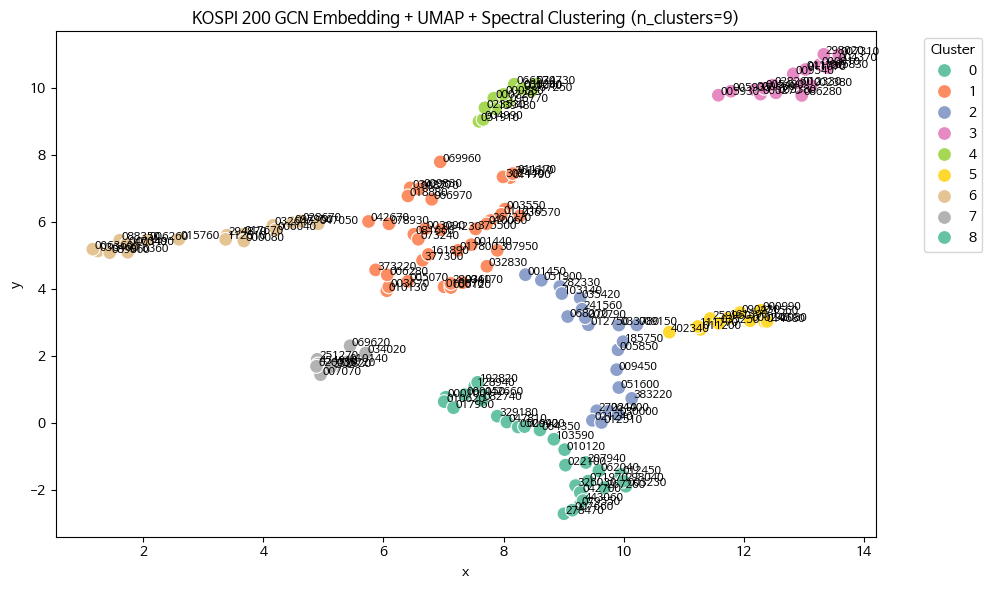


📋 각 클러스터에 속한 기업 목록:
ticker                        name                 sector  cluster
007660                  ISUPETASYS             Technology        0
071970    HD-Hyundai Marine Engine            Industrials        0
278470                         APR     Consumer Defensive        0
326030                        SKBP             Healthcare        0
042700                   HANMISemi             Technology        0
079550                    LIG Nex1            Industrials        0
022100                    POSCO DX             Technology        0
003230                 SamyangFood     Consumer Defensive        0
443060                       HDHMS            Industrials        0
012450     HANWHA AEROSPACE CO LTD            Industrials        0
207940           SAMSUNG BIOLOGICS             Healthcare        0
267260         HD HYUNDAI ELECTRIC            Industrials        0
062040              SANIL ELECTRIC             Technology        0
298040               HYOSUNG HEAVY       

In [64]:
# 📦 라이브러리 불러오기
import sqlite3
import os
import random
import pandas as pd
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import SpectralClustering
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from umap import UMAP

# ✅ 시드 고정 함수 (강화됨)
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(False)

    return seed

# 시드 설정
seed = seed_everything(5)

# 1️⃣ DB에서 재무지표 불러오기
conn = sqlite3.connect('/home/KHLee/hojin/kospi_financials200.db')
selected_columns = [
    'marketCap', 'trailingPE', 'forwardPE', 'returnOnEquity',
    'priceToBook', 'eps', 'recentRevenue', 'profitMargins', 'debtToEquity'
]
query = f"""
SELECT ticker, name, sector, {', '.join(selected_columns)}
FROM financials
"""
df = pd.read_sql(query, conn).dropna()
conn.close()

tickers = df['ticker'].values
names = df['name'].values
sectors = df['sector'].values

features = df[selected_columns].astype(float)
scaled = StandardScaler().fit_transform(features)

# 2️⃣ 재무지표 기반 유사도 계산
S_fund = pd.DataFrame(np.corrcoef(scaled), index=tickers, columns=tickers)

# 3️⃣ 그래프 생성
G = nx.Graph()
for i in tickers:
    G.add_node(i)
    for j in tickers:
        if i != j and S_fund.loc[i, j] > 0.85:
            G.add_edge(i, j, weight=S_fund.loc[i, j])

# ✅ 인덱스 매핑 및 edge_index 생성
ticker_to_idx = {ticker: i for i, ticker in enumerate(tickers)}
edge_list = [(ticker_to_idx[i], ticker_to_idx[j]) for i, j in G.edges if i in ticker_to_idx and j in ticker_to_idx]
edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()

# 4️⃣ 노드 특징 행렬
x = torch.tensor(scaled, dtype=torch.float)

# 5️⃣ GCN 정의
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super(GCN, self).__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = self.conv2(x, edge_index)
        return x

# 6️⃣ 학습 준비
data = Data(x=x, edge_index=edge_index)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(in_channels=x.size(1), hidden_channels=8, out_channels=x.size(1)).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
model.train()
for epoch in range(100):
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.mse_loss(out, data.x)  # autoencoder 방식
    loss.backward()
    optimizer.step()

# 7️⃣ 임베딩 추출
model.eval()
with torch.no_grad():
    z = model(data.x, data.edge_index).cpu().numpy()

# 8️⃣ UMAP 차원 축소
umap_model = UMAP(n_neighbors=10, min_dist=0.3, spread=1.0, random_state=seed,
    transform_seed=seed)
z_umap = umap_model.fit_transform(z)

# 📌 시각화를 위한 데이터프레임 생성
df_plot = pd.DataFrame({
    'ticker': tickers,
    'name': names,
    'sector': sectors,
    'x': z_umap[:, 0],
    'y': z_umap[:, 1]
})

# 9️⃣ Spectral Clustering
sil_scores = []
cluster_range = range(2, 10)
best_score = -1
best_n_clusters = None
best_clusters = None

for n_clusters in cluster_range:
    spectral = SpectralClustering(
        n_clusters=n_clusters,
        affinity='nearest_neighbors',
        assign_labels='kmeans',
        random_state=seed,
        n_jobs=1
    )
    clusters = spectral.fit_predict(z_umap)
    score = silhouette_score(z_umap, clusters)
    sil_scores.append(score)
    print(f"클러스터 수: {n_clusters}, 실루엣 점수: {score:.4f}")
    if score > best_score:
        best_score = score
        best_n_clusters = n_clusters
        best_clusters = clusters

print(f"\n✨ 최적 클러스터 수: {best_n_clusters} (실루엣 점수: {best_score:.4f})")

# 🔟 결과 시각화
df_plot['cluster'] = best_clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_plot, x='x', y='y', hue='cluster', palette='Set2', s=100)
for i in range(len(tickers)):
    plt.text(df_plot['x'][i]+0.03, df_plot['y'][i], df_plot['ticker'][i], fontsize=8)
plt.title(f"KOSPI 200 GCN Embedding + UMAP + Spectral Clustering (n_clusters={best_n_clusters})")
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 📋 클러스터별 기업 목록
df_summary = df_plot[['ticker', 'name', 'sector', 'cluster']].sort_values('cluster')
print("\n📋 각 클러스터에 속한 기업 목록:")
print(df_summary.to_string(index=False))

# ✅ 클러스터별 기업 수 출력
cluster_counts = df_plot["cluster"].value_counts().sort_index()
print("\n📊 클러스터별 기업 수:")
print(cluster_counts)


# 📊 CSV 저장 (선택적으로 주석 해제)
# df_summary.to_csv("/content/clustered_companies_spectral.csv", index=False)
# cluster_counts.to_frame().reset_index().rename(columns={'index': 'Cluster', 'cluster': 'Count'}).to_csv("/content/cluster_counts_spectral.csv", index=False)



In [ ]:
# ✅ 클러스터별 기업 수 출력
cluster_counts = df_plot["cluster"].value_counts().sort_index()
print("\n📊 클러스터별 기업 수:")
print(cluster_counts)
# 📊 클러스터별 재무지표 평균 + 해석
df_plot_with_features = df_plot.copy()
df_plot_with_features[selected_columns] = features.values

cluster_summary = df_plot_with_features.groupby('cluster')[selected_columns].mean().round(2)
print("📊 클러스터별 재무지표 평균:")
print(cluster_summary)

print("\n🧠 클러스터별 해석:")
for cluster, row in cluster_summary.iterrows():
    interpretation = []
    if row['returnOnEquity'] > cluster_summary['returnOnEquity'].mean():
        interpretation.append("ROE(자기자본이익률) 높음 → 수익성 우수")
    if row['debtToEquity'] > cluster_summary['debtToEquity'].mean():
        interpretation.append("부채비율 높음 → 재무레버리지 큼")
    if row['trailingPE'] > cluster_summary['trailingPE'].mean():
        interpretation.append("PER 높음 → 성장 기대 반영")
    if row['profitMargins'] < cluster_summary['profitMargins'].mean():
        interpretation.append("이익률 낮음 → 수익 구조 약함")

    interp_str = " · ".join(interpretation) if interpretation else "전반적으로 평균 수준"
    print(f"📍 Cluster {cluster}: {interp_str}")


📊 클러스터별 기업 수:
cluster
0    54
1    22
2    53
3    27
Name: count, dtype: int64
📊 클러스터별 재무지표 평균:
            marketCap  trailingPE  forwardPE  returnOnEquity  priceToBook  \
cluster                                                                     
0        5.797780e+12       66.09      -1.56            0.07         1.39   
1        4.858116e+13       12.67       9.99            0.19         2.87   
2        7.230202e+12       11.31      11.29            0.02         0.85   
3        8.725973e+12       26.22      24.54            0.16         4.96   

              eps  recentRevenue  profitMargins  debtToEquity  
cluster                                                        
0         5770.72   1.303021e+12           0.08         33.48  
1        24104.41   1.221755e+13           0.11         31.09  
2         4638.72   6.830270e+12           0.00        110.62  
3         3832.67   1.027059e+12           0.07         31.80  

🧠 클러스터별 해석:
📍 Cluster 0: PER 높음 → 성장 기대 반영
📍 Cluster 1

In [ ]:
# 🏷️ 클러스터별 섹터 분포 분석
sector_cluster = df_plot.groupby(['cluster', 'sector']).size().unstack(fill_value=0)
print("\n🏷️ 클러스터별 섹터 분포 (빈도):")
print(sector_cluster)


sector_cluster_pct = sector_cluster.div(sector_cluster.sum(axis=1), axis=0).round(2)
print("\n📊 클러스터별 섹터 비율:")
print(sector_cluster_pct)


🏷️ 클러스터별 섹터 분포 (빈도):
sector   Basic Materials  Communication Services  Consumer Cyclical  \
cluster                                                               
0                      4                       7                  9   
1                      2                       0                  3   
2                      4                       3                  7   
3                      0                       1                  2   

sector   Consumer Defensive  Energy  Financial Services  Healthcare  \
cluster                                                               
0                         8       0                   2           6   
1                         3       0                   2           1   
2                         6       3                   3           2   
3                         1       0                   0           2   

sector   Industrials  Technology  Utilities  
cluster                                      
0                 12           6

# 같은 클러스터 내에 거리 기반으로 유사도 계산하기

In [ ]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist

# 결과를 저장할 리스트
nearest_neighbors_within_cluster = []

for cluster_id in sorted(df_plot['cluster'].unique()):
    cluster_data = df_plot[df_plot['cluster'] == cluster_id].copy()
    embeddings = z[cluster_data.index]

    # 거리 행렬 계산 (n x n)
    distance_matrix = cdist(embeddings, embeddings, metric='euclidean')

    # 거리 정규화 (0과 1 사이로)
    min_distances = distance_matrix.min(axis=1, keepdims=True)
    max_distances = distance_matrix.max(axis=1, keepdims=True)
    distance_matrix = (distance_matrix - min_distances) / (max_distances - min_distances)

    for i, idx in enumerate(cluster_data.index):
        # 자기 자신과의 거리는 무한대로 설정해서 제외
        distance_matrix[i, i] = np.inf

        # 가장 가까운 3개 기업 인덱스
        nearest_idx = distance_matrix[i].argsort()[:3]

        for rank, j in enumerate(nearest_idx, start=1):
            j_idx = cluster_data.index[j]
            neighbor_info = {
                'cluster': cluster_id,
                'source_ticker': df_plot.loc[idx, 'ticker'],
                'source_name': df_plot.loc[idx, 'name'],
                'neighbor_rank': rank,
                'neighbor_ticker': df_plot.loc[j_idx, 'ticker'],
                'neighbor_name': df_plot.loc[j_idx, 'name'],
                'distance': distance_matrix[i, j]
            }
            nearest_neighbors_within_cluster.append(neighbor_info)

# DataFrame으로 정리
nearest_df = pd.DataFrame(nearest_neighbors_within_cluster)

#  결과 확인
print("\n📌 클러스터 내부에서 가까운 기업 TOP 3 (예시 10개):")
print(nearest_df.head(10).to_string(index=False))

#  저장
nearest_df.to_csv("/content/nearest_neighbors_within_cluster.csv", index=False)




📌 클러스터 내부에서 가까운 기업 TOP 3 (예시 10개):
 cluster source_ticker       source_name  neighbor_rank neighbor_ticker             neighbor_name  distance
       0        068270         Celltrion              1          035420                     NAVER  0.144598
       0        068270         Celltrion              2          034230                  PARADISE  0.145934
       0        068270         Celltrion              3          307950           HyundaiAutoever  0.147614
       0        035420             NAVER              1          033780                      KT&G  0.045683
       0        035420             NAVER              2          241560             Doosan Bobcat  0.084767
       0        035420             NAVER              3          051900                    LG H&H  0.097012
       0        259960           KRAFTON              1          011200                       HMM  0.025915
       0        259960           KRAFTON              2          161390 HANKOOK TIRE & TECHNOLOGY  0